# Aula Prática: Pipeline de Machine Learning para Previsão de Churn

- **Objetivo da Aula:** Aplicar um projeto de ponta a ponta para prever o risco de cancelamento de assinaturas (Churn).
- **Base de dados sugerida:** Telco Customer Churn (disponível no Kaggle), que contém informações sobre serviços de telefonia, tempo de contrato e gastos mensais de clientes.

## 1. Entendimento do Negócio

Nesta etapa, o objetivo é estabelecer a forma de abordar o problema e definir como o modelo beneficiará a empresa.
- **O Problema:** Uma empresa de telecomunicações percebeu uma alta taxa de evasão de clientes. Retê-los custa significativamente menos do que adquirir novos.
- **O Objetivo:** Criar um modelo de aprendizado supervisionado (classificação) para modelar a probabilidade de um cliente cancelar o serviço.
- **A Aplicação:** Conforme a pergunta inicial ao "chefe", o modelo será usado para alimentar outro sistema de downstream: os clientes com maior risco (probabilidade $> 0.5$) serão enviados para a equipe de retenção para o oferecimento de descontos.

In [1]:
# Importação das bibliotecas essenciais para manipulação e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 2. Entendimento dos Dados (Data Understanding)

A exploração inicial dos dados nos dá uma rápida descrição dos atributos numéricos e categóricos.

- **Exploração Básica:** Carregar a base via pandas e utilizar métodos como .head(), .info() e .describe() para ter uma visão geral do conjunto de dados.

- **Análise de Atributos:** Identificar a variável target (Churn: Yes/No) e as features (preditores), como tenure (meses de contrato) e MonthlyCharges (gasto mensal).

In [2]:
# Carregando os dados
url_dataset = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url_dataset)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Informações sobre o dataframe
# object = tipo texto / string
# int64 = número inteiro
# float64 = número decimal
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Atributo dtypes: identifica os tipos de variáveis
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
# Dados estatísticos
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Conhecendo as Features**
- *gender:* Whether the customer is a male or a female
- *SeniorCitizen:* Whether the customer is a senior citizen or not (1, 0)
- *Partner:* Whether the customer has a partner or not (Yes, No)
- *Dependents:* Whether the customer has dependents or not (Yes, No)
- *tenure:* Number of months the customer has stayed with the company
- *PhoneService:* Whether the customer has a phone service or not (Yes, No)
- *MultipleLines:* Whether the customer has multiple lines or not (Yes, No, No phone service)
- *InternetService:* Customer’s internet service provider (DSL, Fiber optic, No)
- *OnlineSecurity:* Whether the customer has online security or not (Yes, No, No internet service)
- *OnlineBackup:* Whether the customer has online backup or not (Yes, No, No internet service)
- *DeviceProtection:* Whether the customer has device protection or not (Yes, No, No internet service)
- *TechSupport:* Whether the customer has tech support or not (Yes, No, No internet service)
- *StreamingTV:* Whether the customer has streaming TV or not (Yes, No, No internet service)
- *StreamingMovies:* Whether the customer has streaming movies or not (Yes, No, No internet service)
- *Contract:* The contract term of the customer (Month-to-month, One year, Two year)
- *PaperlessBilling:* Whether the customer has paperless billing or not (Yes, No)
- *PaymentMethod:* The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
- *MonthlyCharges:* The amount charged to the customer monthly
- *TotalCharges:* The total amount charged to the customer
- *Churn:* Whether the customer churned or not (Yes or No)

Antes de aplicar qualquer algoritmo complexo, precisamos entender como os nossos clientes se comportam, identificar a distribuição das variáveis e formular as primeiras hipóteses sobre o que leva um cliente a cancelar o serviço (Churn).

Vamos agrupar nossas 21 variáveis em 4 categorias principais para facilitar a análise:

- Dados Demográficos: gender, SeniorCitizen, Partner, Dependents.

- Serviços Contratados: PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies.

- Dados de Conta/Contrato: tenure, Contract, PaperlessBilling, PaymentMethod.

- Dados Financeiros: MonthlyCharges, TotalCharges.

In [13]:
# Tranformando a variáel TotalCharges em numérica
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True) # remove linhas que tenham pelo menos um NaN.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

**Alvo:**

Toda a nossa modelagem será focada em prever a coluna Churn. Vamos analisar o tamanho do nosso problema.

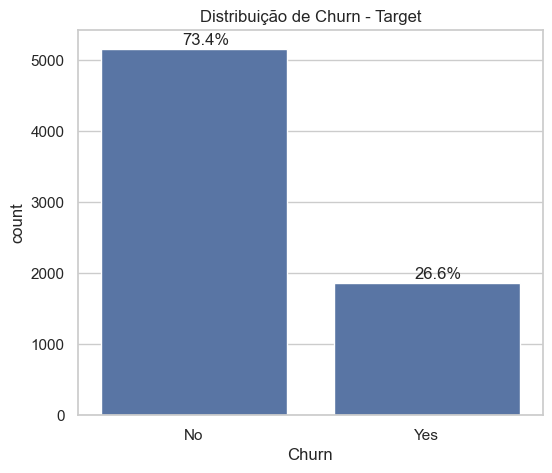

In [19]:
plt.figure(figsize=(6,5)) #largura 6, altura 5
ax = sns.countplot(data = df, x='Churn') #conta quantas vezes cada valor aparece em Churn
plt.title('Distribuição de Churn - Target')

#Adicionando os percentuais em cima das barras
total = len(df) #conta quantas linhas existem no DataFrame
for p in ax.patches: 
    #ax.patches = lista de barras do gráfico, logo, cada p representa uma barra
    percentage = f'{100 * p.get_height() / total:.1f}%' # calculando pocentagem
    x = p.get_x() + p.get_width() / 2 - 0.05 # centraliza o texto no meio da barra
    y = p.get_height() + 50 # coloca o texto um pouco acima da barra
    ax.annotate(percentage, (x,y), size = 12) #escreve a porcentagem no gráfico

**Interpretação (Target):**

Temos um _desbalanceamento_ de classes: 73,4% dos clientes permaneceram na empresa e 26,6% cancelaram.

**O que isso significa para a modelagem?** Se um modelo disser que ninguém vai cancelar, ele acertará 73,4% das vezes (alta acurácia), mas será completamente inútil para o negócio. É por isso que, mais tarde, focaremos em métricas como Recall e F1-Score em vez da Acurácia simples.

**Análise do Perfil Demográfico:**

Será que o gênero, a idade ou a constituição familiar influenciam na decisão de manter ou cancelar o serviço?

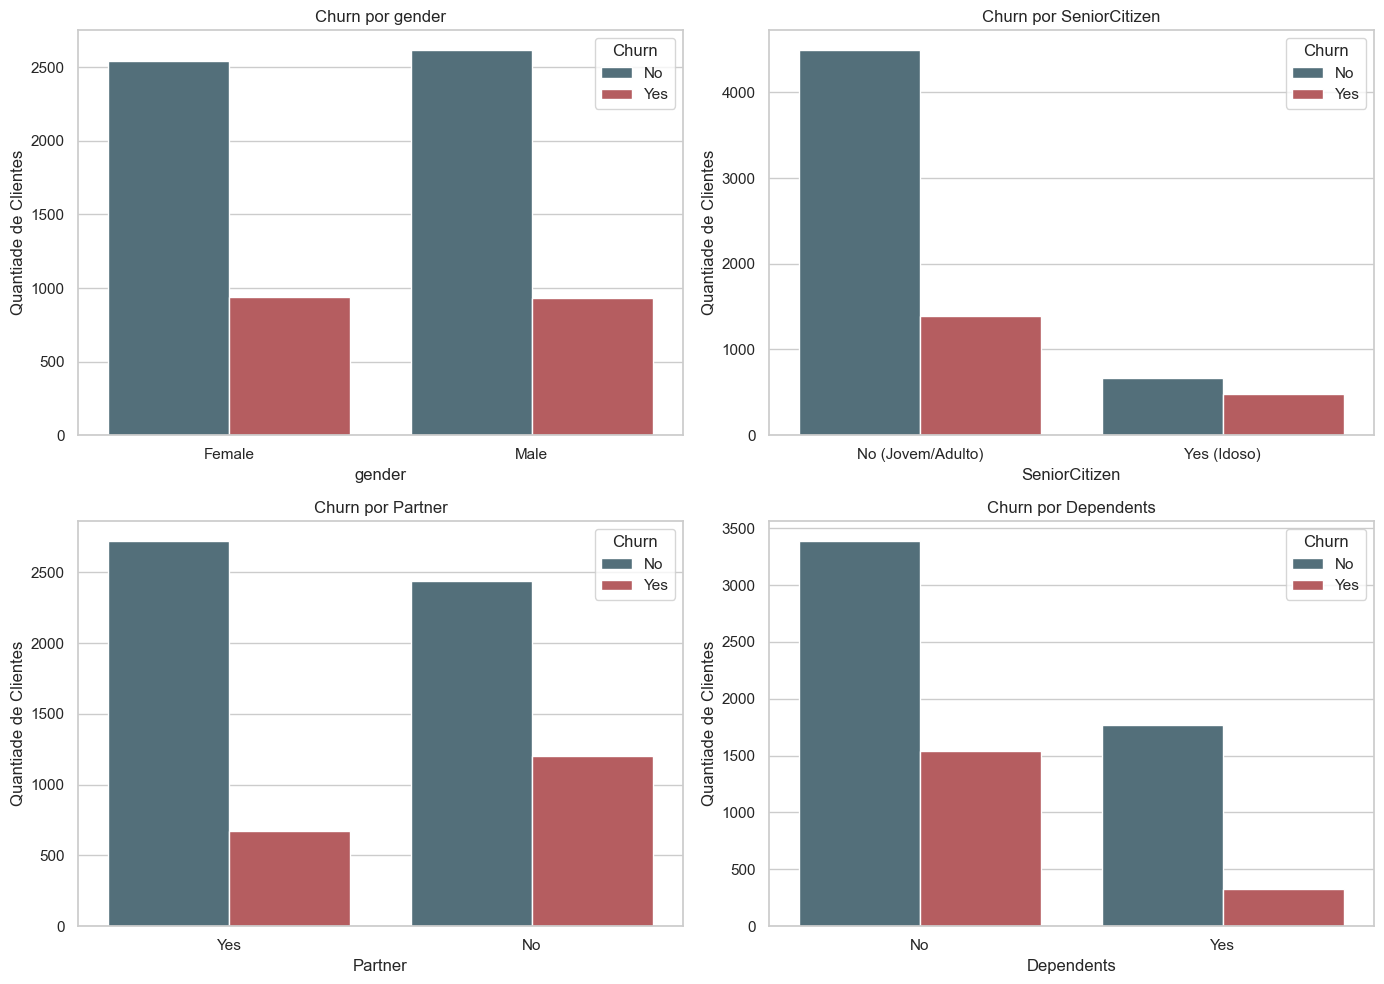

In [22]:
demograficos = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(demograficos): #i = indice, col= nome da coluna
    ax = axes[i//2, i%2] #transforma o índice em posição na grade, ex: (0,0), (0,1) ...
    # Mapeando SeniorCitizen
    plot_data = df.copy()
    if col == 'SeniorCitizen':
        plot_data[col] = plot_data[col].map({0:'No (Jovem/Adulto)', 1:'Yes (Idoso)'})

    sns.countplot(data=plot_data, x=col, hue='Churn', palette=['#4C7280','#c44E52'], ax=ax)
    ax.set_title(f'Churn por {col}', fontsize=12)
    ax.set_ylabel('Quantiade de Clientes')
    
plt.tight_layout()
plt.show()

Interpretação (Demográficos):

- Gênero (gender): As taxas de evasão são praticamente idênticas entre homens e mulheres. O gênero não parece ser um bom discriminador para o Churn.
- Idosos (SeniorCitizen): A maioria dos clientes não é idosa e a proporção de Churn entre os não idosos é visivelmente maior.
- Parceiros e Dependentes (Partner, Dependents): Clientes sem parceiros (solteiros) e sem dependentes (filhos/familiares) cancelam muito mais.
- **Insights para Negócio:** Clientes com família (parceiros/dependentes) tendem a buscar estabilidade. Vender "planos familiares" pode ser uma estratégia de retenção.

**Análise de Serviços Contratados:**

A empresa oferece serviços de telefonia e internet. Como a ausência ou presença de certos serviços afeta a lealdade do cliente?

**Interpretação (Serviços):**

- Tipo de Internet (InternetService): Este é um achado crítico! Clientes com Fibra Óptica (Fiber optic) cancelam muito mais do que aqueles com DSL. A fibra óptica da empresa está com problemas de estabilidade? Ou o preço é muito alto frente à concorrência?
- Segurança e Suporte (OnlineSecurity, TechSupport): Clientes que não possuem os pacotes de segurança online e suporte técnico lideram o número de cancelamentos.
- **Insights para Negócio:** Oferecer suporte técnico e segurança como cortesia ou com grandes descontos nos primeiros meses pode criar atrito na hora de cancelar, aumentando a retenção.

**Análise de Dados de Contrato e Variáveis Numéricas:**

O aspecto financeiro e o tipo de vínculo que o cliente assina costumam ser os maiores determinantes do Churn. Vamos olhar para o tipo de contrato (Contract), o tempo de permanência (tenure) e a mensalidade (MonthlyCharges).

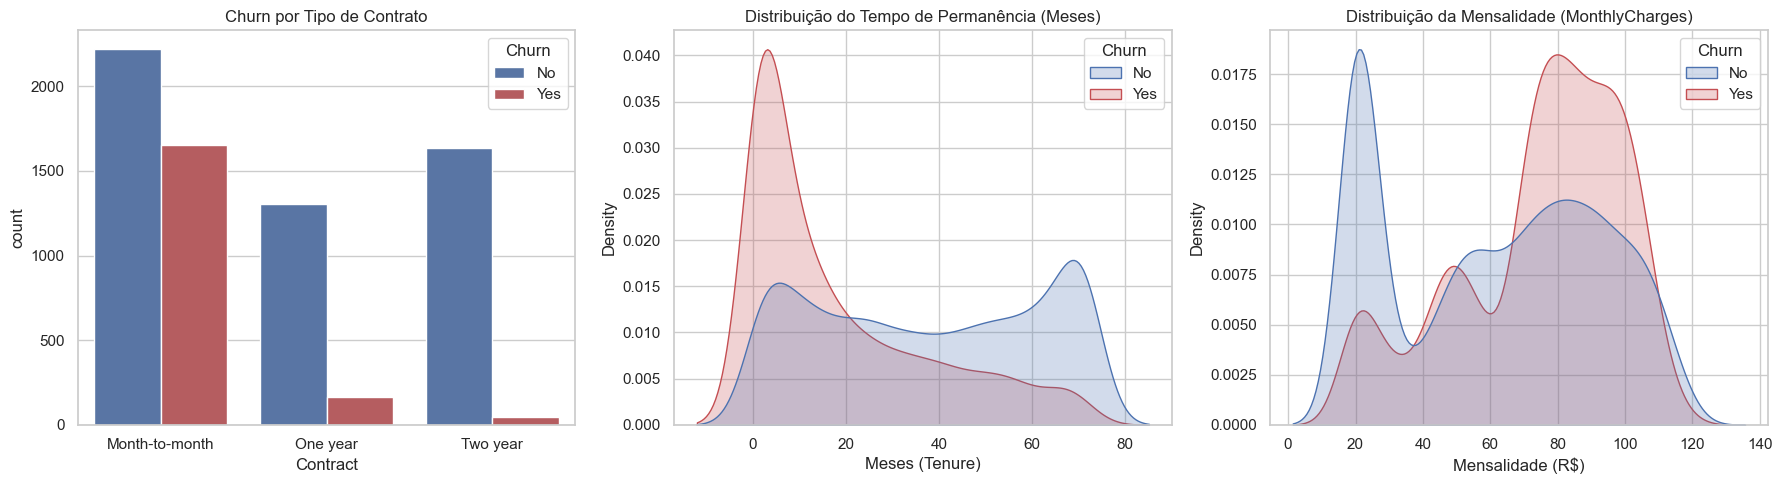

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#1. Gráfico de Barras para Tipo de Contrato
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#4C72B0', '#C44E52'], ax=axes[0])
axes[0].set_title('Churn por Tipo de Contrato')

#2. KDE Plot (Distribuição) para tempo de Permanência (Tenure)
sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, fill=True,palette=['#4C72B0', '#C44E52'], ax=axes[1])
axes[1].set_title('Distribuição do Tempo de Permanência (Meses)')
axes[1].set_xlabel('Meses (Tenure)')

#3. KDE Plot para Pagamento Mensal
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', common_norm=False, fill=True,palette=['#4C72B0', '#C44E52'], ax=axes[2])
axes[2].set_title('Distribuição da Mensalidade (MonthlyCharges)')
axes[2].set_xlabel('Mensalidade (R$)')

plt.tight_layout()
plt.show()

**Interpretação:**
- Contrato (Contract): Contratos mensais (Month-to-month) têm uma taxa de Churn avassaladora. Clientes presos em contratos anuais ou bianuais (One/Two year) quase não cancelam (provavelmente devido a multas de quebra de contrato).
- Tempo de Casa (tenure): A curva vermelha (Churn) tem um pico logo no início. A maioria dos cancelamentos ocorre nos primeiros 5 meses. Se a empresa reter o cliente nos primeiros 6 meses, a chance de ele ficar a longo prazo aumenta muito.
- Mensalidade (MonthlyCharges): Há um pico claro de cancelamentos (curva vermelha) para clientes que pagam faturas altas (entre 70 e 100 dólares/reais). Curiosamente, clientes que pagam muito pouco (em torno de 20) têm alta taxa de retenção.
- **Insights para Negócio:** O foco absoluto da equipe de Customer Success deve ser na integração (onboarding) dos novos clientes nos meses 1 a 5, especialmente aqueles em contratos mensais e com faturas altas (possivelmente os clientes de Fibra Óptica).

**Conclusão:**

1. As "Campeãs" (Variáveis Fortes - Manter)

Estas são as variáveis que mostraram uma correlação visual e de negócio muito clara com a evasão. Elas serão o núcleo do nosso modelo:

- Contrato (Contract): A variável mais forte. Contratos mensais são o maior indicador de risco.

- Tempo de Permanência (tenure): Clientes novos (0 a 5 meses) estão na zona de perigo.

- Mensalidade (MonthlyCharges): Mensalidades altas indicam maior propensão ao cancelamento.

- Tipo de Internet (InternetService): O serviço de Fibra Óptica apresentou problemas crônicos de retenção.

- Segurança e Suporte (OnlineSecurity, TechSupport): A ausência desses serviços deixa o cliente vulnerável a cancelar.

2. Oportunidades de Feature Engineering (Transformar)

Podemos criar novas variáveis a partir das existentes para ajudar o modelo a capturar melhor o comportamento do cliente:

- Perfil Familiar: Vimos que Partner (Parceiro) e Dependents (Dependentes) reduzem o Churn. Podemos combinar essas duas em uma única coluna chamada HasFamily (1 para sim, 0 para não), simplificando a dimensão dos dados.

- Agrupamento de Tenure (Binning): Em vez de tratar o tenure como um número contínuo, podemos criar grupos como "Novo (0-6 meses)", "Regular (6-24 meses)" e "Fiel (+24 meses)".


In [24]:
# Criando uma cópia do dataframe
df_model = df.copy()

In [25]:
# Criando a feature 'HasFamily': se tem parceiro ou dependente (1), caso contrário (0)
df_model['HasFamily'] = ((df_model['Partner'] == 'Yes') | (df_model['Dependents'] == 'Yes')).astype(int)

In [31]:
df_model['HasFamily']

0       1
1       0
2       0
3       0
4       0
       ..
7038    1
7039    1
7040    1
7041    1
7042    0
Name: HasFamily, Length: 7032, dtype: int64

In [32]:
# Definir os limites (bins) para os grupos
# -1 - 6 = Novos (-1 só para garantir que o 0 esteja incluído)
# 6 a 24 = Regular
# 24 ao infinito (np.inf) = Fiel

limites = [-1, 6, 24, np.inf]

In [33]:
# Definindo os rótulos (nomes das categorias)
rotulos = ['Novo (0-6 meses)', 'Regular (6-24 meses)', 'Fiel (+24 meses)']

In [34]:
# Aplicando os rótulos
df_model['TenureGroup'] = pd.cut(df_model['tenure'], bins=limites, labels=rotulos)
df_model['TenureGroup']

0           Novo (0-6 meses)
1           Fiel (+24 meses)
2           Novo (0-6 meses)
3           Fiel (+24 meses)
4           Novo (0-6 meses)
                ...         
7038    Regular (6-24 meses)
7039        Fiel (+24 meses)
7040    Regular (6-24 meses)
7041        Novo (0-6 meses)
7042        Fiel (+24 meses)
Name: TenureGroup, Length: 7032, dtype: category
Categories (3, object): ['Novo (0-6 meses)' < 'Regular (6-24 meses)' < 'Fiel (+24 meses)']

In [35]:
df_model['TenureGroup'].value_counts()

TenureGroup
Fiel (+24 meses)        3833
Regular (6-24 meses)    1729
Novo (0-6 meses)        1470
Name: count, dtype: int64

In [36]:
df_model.drop(columns=['tenure'], inplace=True)

In [37]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   object  
 1   gender            7032 non-null   object  
 2   SeniorCitizen     7032 non-null   int64   
 3   Partner           7032 non-null   object  
 4   Dependents        7032 non-null   object  
 5   PhoneService      7032 non-null   object  
 6   MultipleLines     7032 non-null   object  
 7   InternetService   7032 non-null   object  
 8   OnlineSecurity    7032 non-null   object  
 9   OnlineBackup      7032 non-null   object  
 10  DeviceProtection  7032 non-null   object  
 11  TechSupport       7032 non-null   object  
 12  StreamingTV       7032 non-null   object  
 13  StreamingMovies   7032 non-null   object  
 14  Contract          7032 non-null   object  
 15  PaperlessBilling  7032 non-null   object  
 16  PaymentMethod     7032 non-nu

3. O "Ruído" (Variáveis Fracas - Descartar)

Estas variáveis não demonstraram poder discriminatório significativo durante a análise e podem ser removidas (drop) para simplificar o modelo:

- Gênero (gender): A proporção de Churn foi rigorosamente igual entre homens e mulheres. O algoritmo não aprenderá nada com isso.
- Serviço de Telefone (PhoneService): A imensa maioria dos clientes possui esse serviço, e a taxa de evasão não muda muito para quem não tem.
- ID do Cliente (customerID): Identificadores únicos nunca devem entrar em modelos preditivos (já removemos no início).

In [38]:
df_model.drop(columns=['gender', 'PhoneService', 'Partner', 'Dependents', 'customerID'], inplace=True)

In [39]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7032 non-null   int64   
 1   MultipleLines     7032 non-null   object  
 2   InternetService   7032 non-null   object  
 3   OnlineSecurity    7032 non-null   object  
 4   OnlineBackup      7032 non-null   object  
 5   DeviceProtection  7032 non-null   object  
 6   TechSupport       7032 non-null   object  
 7   StreamingTV       7032 non-null   object  
 8   StreamingMovies   7032 non-null   object  
 9   Contract          7032 non-null   object  
 10  PaperlessBilling  7032 non-null   object  
 11  PaymentMethod     7032 non-null   object  
 12  MonthlyCharges    7032 non-null   float64 
 13  TotalCharges      7032 non-null   float64 
 14  Churn             7032 non-null   object  
 15  HasFamily         7032 non-null   int64   
 16  TenureGroup       7032 non-nu

## 3. Preparação dos Dados (Data Preparation)
A sequência de componentes de processamento e limpeza formará o nosso pipeline de dados.
- **Verificação de Nulos:** Usar o método df.isnull().sum() para identificar dados faltantes que precisarão de tratamento na próxima fase.

- **Identificação de outliers:** Usar métodos estatísticos para identificação de possíveis valores anômalos.

- **Tratamento de variáveis:** Transformar features numéricas (normalização ou padronização) e features categóricas (onehot encoding, ordinal encoding).

In [40]:
# Quantidade de dados nulos por coluna
df_model.isna().sum()

SeniorCitizen       0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
HasFamily           0
TenureGroup         0
dtype: int64

In [41]:
# Definir as features e o target
y = df_model['Churn']
x = df_model.drop(columns=['Churn'])

In [42]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7032 non-null   int64   
 1   MultipleLines     7032 non-null   object  
 2   InternetService   7032 non-null   object  
 3   OnlineSecurity    7032 non-null   object  
 4   OnlineBackup      7032 non-null   object  
 5   DeviceProtection  7032 non-null   object  
 6   TechSupport       7032 non-null   object  
 7   StreamingTV       7032 non-null   object  
 8   StreamingMovies   7032 non-null   object  
 9   Contract          7032 non-null   object  
 10  PaperlessBilling  7032 non-null   object  
 11  PaymentMethod     7032 non-null   object  
 12  MonthlyCharges    7032 non-null   float64 
 13  TotalCharges      7032 non-null   float64 
 14  HasFamily         7032 non-null   int64   
 15  TenureGroup       7032 non-null   category
dtypes: category(1), float64(2), i

In [43]:
# Separando treino e teste
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, u_train, y_test = train_test_split(x, y , test_size=25, random_state=42)

In [46]:
#Obter as colunas numéricas e categóricas
colunas_categoricas = X_train.select_dtypes('object').columns.to_list()
#Obter as colunas numéricas
colunas_numericas = X_train.select_dtypes('number').columns.to_list()

In [47]:
colunas_categoricas

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [48]:
colunas_numericas

['SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'HasFamily']

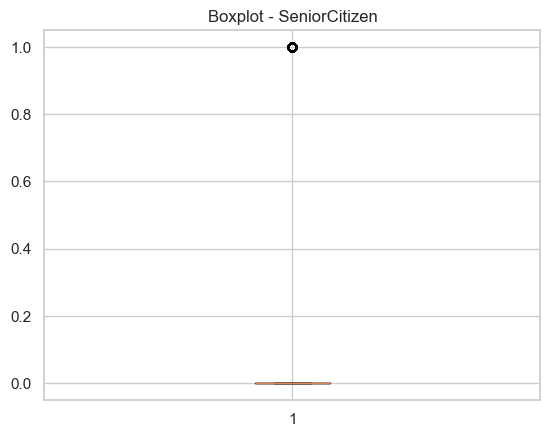

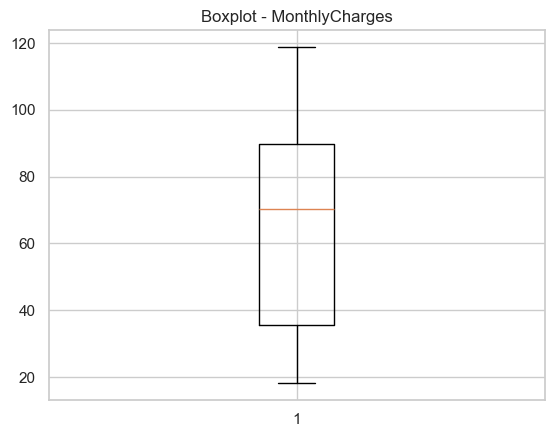

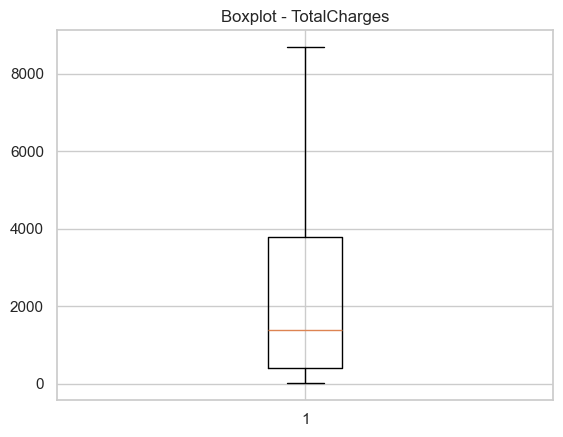

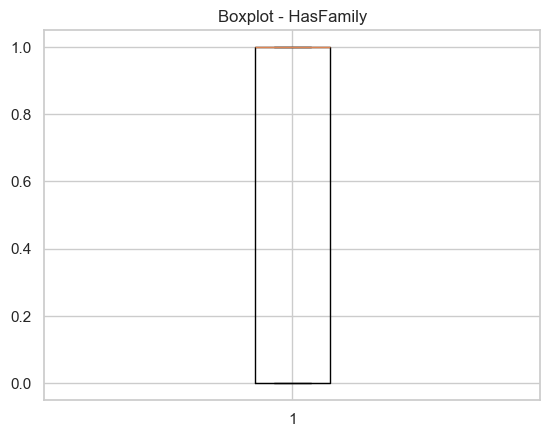

In [49]:
for col in colunas_numericas:
    plt.figure()  # cria uma nova figura para cada coluna
    plt.boxplot(df_model[col].dropna())
    plt.title(f'Boxplot - {col}')
    plt.show()

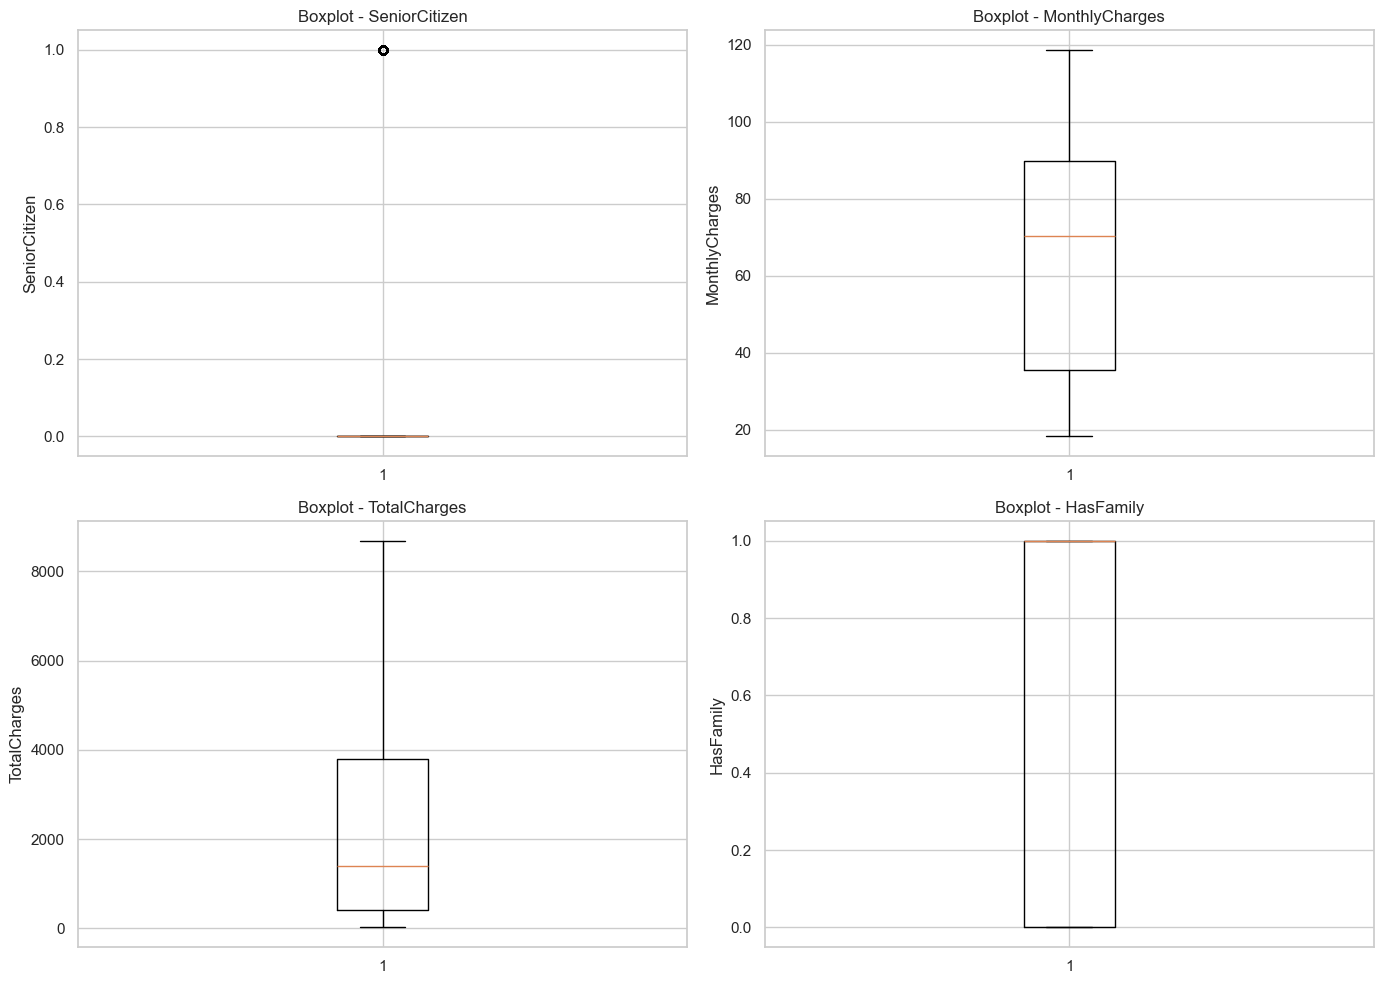

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Transforma em lista para facilitar o loop
axes = axes.flatten()

# Loop pelas colunas numéricas
for i, col in enumerate(colunas_numericas):
    # Cria o boxplot no subplot correspondente
    axes[i].boxplot(df_model[col].dropna())
    # Define título
    axes[i].set_title(f'Boxplot - {col}')
    # (opcional) nome do eixo Y
    axes[i].set_ylabel(col)
# Remove gráficos vazios, caso tenha menos de 4 colunas
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

In [51]:
# Transformando tudo que é "No internet service" ou "No phone service" apenas em "No"
df_model = df_model.replace({'No internet service': 'No', 'No phone service': 'No'})

# E então aplicar a transformação Yes/No para 1/0
df_model = df_model.replace({'Yes': 1, 'No': 0})

In [52]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   SeniorCitizen     7032 non-null   int64   
 1   MultipleLines     7032 non-null   int64   
 2   InternetService   7032 non-null   object  
 3   OnlineSecurity    7032 non-null   int64   
 4   OnlineBackup      7032 non-null   int64   
 5   DeviceProtection  7032 non-null   int64   
 6   TechSupport       7032 non-null   int64   
 7   StreamingTV       7032 non-null   int64   
 8   StreamingMovies   7032 non-null   int64   
 9   Contract          7032 non-null   object  
 10  PaperlessBilling  7032 non-null   int64   
 11  PaymentMethod     7032 non-null   object  
 12  MonthlyCharges    7032 non-null   float64 
 13  TotalCharges      7032 non-null   float64 
 14  Churn             7032 non-null   int64   
 15  HasFamily         7032 non-null   int64   
 16  TenureGroup       7032 non-nu

In [53]:
colunas_numericas_corr = df_model.select_dtypes(include=['number'])

In [54]:
# matriz de correlação
# +-1 = relação perfeita, não é o mesmo que causalidade
# 0 = sem relação
matriz_correl = colunas_numericas_corr.corr() 

In [55]:
# Mostra correlação das variáveis com 'Churn', ordenando do maior para o menor
matriz_correl['Churn'].sort_values(ascending = False)

Churn               1.000000
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
StreamingTV         0.063254
StreamingMovies     0.060860
MultipleLines       0.040033
DeviceProtection   -0.066193
OnlineBackup       -0.082307
HasFamily          -0.162113
TechSupport        -0.164716
OnlineSecurity     -0.171270
TotalCharges       -0.199484
Name: Churn, dtype: float64

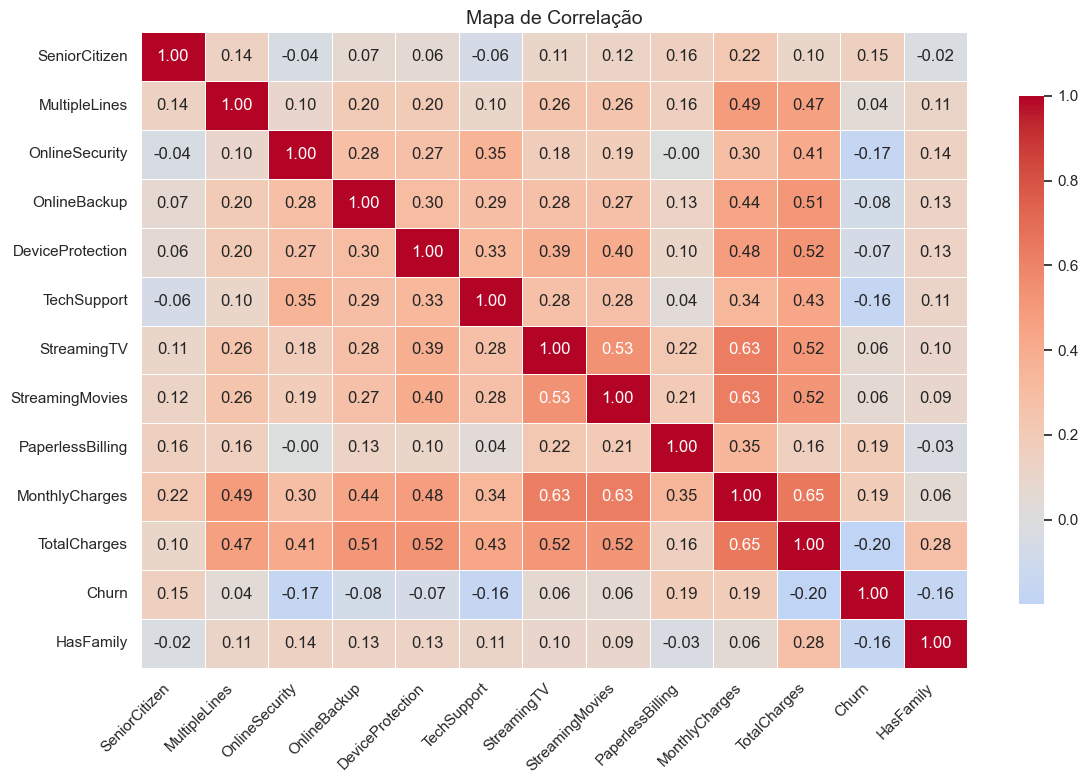

In [58]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    matriz_correl,
    annot=True,            # mostra os valores
    fmt=".2f",             # 2 casas decimais
    cmap="coolwarm",       # cores (azul → negativo | vermelho → positivo)
    center=0,              # centraliza no zero
    linewidths=0.5,        # linhas entre células
    cbar_kws={"shrink": 0.8}  # barra de cores menor
)

plt.title('Mapa de Correlação', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [59]:
from sklearn.model_selection import cross_validate, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [60]:
!pip install category_encoders

In [61]:
from category_encoders import OneHotEncoder, TargetEncoder

## 4. Modelagem (Modeling)
Agora vamos implementar os modelos supervisionados abordados: KNN, Regressão Logística e Árvores de Decisão utilizando o pipeline de treinamento do scikit-learn (fit, predict).

### Aprendizado de Máquina

O aprendizado de máquina (Machine Learning) é um sistema que pode modificar seu comportamento de forma autônoma com base na sua própria experiência. Esta experiência é o treinamento abordado anteriormente.

![](https://miro.medium.com/v2/resize:fit:1400/1*Yc2IqYEFlr2VzT87s2f6fw.jpeg)

#### Aprendizado supervisionado

Focaremos nos modelos de aprendizado supervisionado. Neste tipo de problema há basicamente 2 tarefas:
- Regressão
- Classificação

A *classificação* é uma típica tarefa de aprendizado de máquina supervisionado. O filtro de spam é um bom exemplo: ele é treinado com muitos exemplos de e-mails junto às classes (spam ou ham) e deve aprender a classificar e-mails novos.

Outra tarefa típica é **prever um valor numérico alvo** ou *target*, como o preço de um carro, dado um conjunto de características [*features*] (quilometragem, tempo de uso, marca, etc.), chamdos de **preditores**. Esse tipo de tarefa recebe o nome de *regressão*. Para treinar o sistema, é necessário fornecer muitos exemplos de carros, incluindo seus preditores e rótulos (seus preços).

Alguns dos algoritmos mais importantes do aprendizado supervisionado serão abordados:
> * [ ] K-ésimo vizinho mais próximo
> * [ ] Regressão Linear
> * [ ] Regressão Logística
> * [ ] Árvores de decisão e florestas aleatórias

### KNeighboursClassifier

É um algoritmo de aprendizado supervisionado (que inicialmente veremos no contexto de classificação): o KNN, que é a sigla de **k nearest neighbors**, ou seja, **k vizinhos mais próximos**.

A ideia é bem simples: tomamos uma base de treino classificada (supervisionada).

A cada observação de teste que queiramos classificar, tomamos **a classe como sendo a classe das $k$ observações que estão mais próximas do elemento a ser classificado**

<img src="https://res.cloudinary.com/dyd911kmh/image/upload/f_auto,q_auto:best/v1531424125/KNN_final1_ibdm8a.png" width=600>

Este algoritmo é muito simples e intuitivo, mas há dois elementos de extrema importância:

> Como medir a **distância** entre dados? Qual é a **métrica** adequada?

Veremos que o sklearn nos permite escolher diferentes métricas de distância, o que é ótimo, pois assim podemos seguir a habitual abordagem: testar diferentes métricas, e escolher a que der melhores resultados!

> Qual é o número de vizinhos adequados: i.e., **como escolher $k$?**

Essa é uma escolha particularmente importante, pois escolhas diferentes de $k$ podem facilmente levar a classificações diferentes:

<img src="https://helloacm.com/wp-content/uploads/2016/03/2012-10-26-knn-concept.png" width=400>

Veremos logo como escolher bons valores!

> **Reflita e responda**: como a escolha de $k$ influencia a performance de generalização do modelo (isto é, seu comportamento no que diz respeito ao trade-off viés-variância)?
><br><br>Dica: pense no que acontece nos extremos, $k=1$ e $k=N$, ond $N$ é o número de observações na base de treino.

Conclusão:

- $k=1$ temos alta variância (overfitting - pense nos outliers!).

- $k=N$ temos alto viés (underfitting - não aprendemos nada, só predizemos diretamente a classe majoritária na base de treino).

As etapas do algoritmo são as seguintes:

1. Recebe um dado não classificado;
2. Mede sua distância (Euclidiana, Manhattan, Minkowski ou Ponderada) de cada um dos elementos da base de treino;
3. Obtém um *ranking* das distâncias, em ordem decrescente;
4. Verifica a classe de cada da um dos *K* dados que tiveram a menor distância e conta a quantidade de cada classe;
5. Toma como resultado a classe que mais apareceu dentre os dados que tiveram as menores distâncias;
6. Classifica o novo dado com a classe tomada como resultado da classificação.

KNN é um método LAZY LEARNER -- Ou seja, **não há uma etapa explícita de treinamento**, conforme vimos antes.

Cada observação de teste é classificada por vez, segundo o passo a passo acima.

> **MUITO IMPORTANTE**: sempre devemos **escalar os dados** quando formos construir um modelo KNN! Reflita: por quê?

### Regressão Linear

Durante a análise é possível notar que uma **reta** pode ser **traçada entre os pontos do gráfico**. E essa reta traçada pode ser usada para **predição de valores!**

Vimos na aula passada que para modelarmos a relação `open` e `close`, usamos o modelo de **Regressão Linear Simples**.

Mas afinal, o que é a **Regressão Linear**?

Como o próprio nome diz, o modelo de Regressão Linear será **uma reta (polinômio linear)**, que melhor se ajusta aos seus dados!

O modelo de **Regressão Linear Simples** será uma linha reta que relaciona Y (o preço da casa) e X (os atributos da casa).

Se utilizarmos **apenas um atributo** (como, por exemplo, a área construída), temos uma **Regressão Linear Simples**, e nosso modelo é:

$$ \hat{y} = b_0 + b_1 X $$

Neste caso, o modelo tem dois coeficientes (ou **parâmetros**) a serem determinados: $b_0$ (intercepto ou coeficiente linear) e $b_1$ (coeficiente angular).

A equação acima exprime a **forma funcional** do conjunto de hipóteses com o qual trabalharemos: funções lineares, de uma úniva variável. Isto é,

$$ f_{H, \vec{b}} = b_0 + b_1 X $$

Ou seja,

$$ \mathcal{H} = \{ f_{H, \vec{b}}\} = \{ b_0 + b_1 X \} $$

é o conjunto de hipóteses que está sendo considerado, e o vetor de parâmetros é:

$$\vec{b} = \begin{bmatrix}
b_0\\
b_1
\end{bmatrix}$$

O **algoritmo de aprendizagem** do estimador é utilizado justamente para encontrarmos os coeficientes $b_0$ e $b_1$ (isto é, o vetor de parâmetros) **que melhor se ajustam aos dados!**

Para fazer isso, pode-se utilizar o método dos **mínimos quadrados** (OLS  - ordinary least squares) ou então o [gradiente descendente](https://towardsdatascience.com/linear-regression-using-gradient-descent-97a6c8700931).

**Vamos conhecer o OLS!**

**Como o algoritmo traça a melhor reta?**

De maneira esquemática, um algoritmo de aprendizagem recebe:

- Um conjunto de hipóteses $\mathcal{H}$;
- Um conjunto de dados de treino $\left(X_i, y_i \right)$

![](http://keytodatascience.com/wp-content/uploads/2022/02/Linear-regression-gradient-descent-optimization.gif)

Uma vez que temos uma função de custo, nosso objetivo passa a ser **minimizá-la**. E isso faz total sentido: queremos que nosso modelo, após ter "aprendido", erre o mínimo possível!

Por isso, naturalmente caímos em um **problema de otimização**. Mas, a pergunta que surge é: queremos minimizar o erro **com relação a que?**

Agora, é importante lembrarmos que a **função hipótese é parametrizada**. E é justamente o vetor de parâmetros que determina **a reta que melhor se ajusta aos dados**.

Assim, podemos resumir o objetivo do algoritmo de aprendizagem como:

> Determinar o vetor de parâmetros que minimiza a função de custo nos dados de treino

E isso faz total sentido, não é mesmo?

**E esse é o algoritmo de aprendizagem da regressão linear!**

---

Agora temos os dados, escolhemos o conjunto de hipóteses, e conhecemos também o algoritmo de treinamento da regressão linear!

Felizmente, não precisamos implementar este algoritmo na mão (embora, caso queira, fique à vontade! É um ótimo exercício!)

Aqui na aula, usaremos o sklearn para isso!

### Regressão Logística



A [Regressão Logística](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) (também chamado de **logit**), apesar do nome, é um método que aplicaremos a problemas de classificação!

O objetivo da regressão logística é: **modelar a probabilidade $P(\vec{x})$ de dada observação (com features $\vec{x}$) pertencer à classe 1**, ou seja, queremos modelar:

$$ P( y = 1 | \vec{x}) $$

Naturalmente, $0 \le P(\vec{x}) \le 1$.

> Lembre-se que: $ P( y = 0 | \vec{x}) = 1 - P( y = 1 | \vec{x}) $

Uma vez que tivermos uma função que modele a probabilidade acima, podemos tomar a decisão de classificação da seguinte maneira:

- $P(\vec{x}) \ge 0,5$: x pertence à classe 1
- $P(\vec{x}) < 0.5$: x pertence à classe 0

Obs.: este valor de 0.5 (50%) é chamado de "cutoff", e pode ser ajustado, embora seja comum fixá-lo em 50%!

Poderíamos pensar em utilizar a regressão linear em nossos problemas de classificação, mas isso não é uma boa ideia: acabamos encontrando probabilidades negativas e fit ruim!

No exemplo a seguir, temos a probabilidade de não-pagamento (default) de um empréstimo com base em uma feature (balanço). Note probabilidades negativas!

<figure>
    <img src="https://s3-sa-east-1.amazonaws.com/lcpi/70189f79-2886-4e59-893b-1dac9dd64078.png" height="400" width="400">
</figure>

Para resolver este problema, podemos adaptar a função de regressão linear para uma função que tem imagem entre 0 e 1. Seria legal se tivéssemos algo como:

<figure>
    <img src="https://s3-sa-east-1.amazonaws.com/lcpi/6d54529a-d295-47a3-8a11-1f426fde7229.png" height="400" width="400">
</figure>

Um exemplo de tal função é a **função logística** ou **função sigmoidal**:

<img src="https://miro.medium.com/max/970/1*Xu7B5y9gp0iL5ooBj7LtWw.png" width=400>

Note que:

- $z \in \mathbb{R}$
- $0 \le \phi(z) \le 1$

Para incorporar a ideia da regressão linear na regressão logística, tomamos:

- $z = b_0 + b_1x$, que é o modelo de regressão linear (uma variável);

E substituímos na função logística:

- $\phi(x) = \frac{1}{1 + e^{-(b_0 + b_1 x)}}$

Com isso, tomamos qualquer output real do modelo linear e transformamos em um valor entre 0 e 1, como queríamos!

<img src="https://s3-sa-east-1.amazonaws.com/lcpi/e5ecf372-6790-49db-9bad-95bc4b19df27.png" width="500">

No nosso caso, como queremos modelar probabilidades, a função acima é exatamente a **hipótese** do estimador de regressão logística! Isto é,

$$f_{H, \vec{b}}(x) = P(x) = \frac{1}{1 + e^{-(b_0 + b_1 x)}}$$

Ou, para a regressão logística múltipla com $p$ features $\vec{x} = x_1, \cdots, x_p$:

$$f_{H, \vec{b}}(\vec{x}) = P(\vec{x}) = \frac{1}{1 + e^{-(b_0 + b_1 x_1 + \cdots + b_p x_p)}}$$

Com um pouco de álgebra, é possível mostrar que:

$ b_0 + b_1 x_1 + \cdots + b_p x_p = \log \left ( \frac{P}{1-P} \right ) $

A quantidade $\frac{P}{1-P}$ é conhecida como **odds/chance**; e $\log \left ( \frac{P}{1-P} \right )$ é o [log-odds ou logit](https://en.wikipedia.org/wiki/Logit).

Note, portanto, que podemos entender a regressão logística como um modelo em que **o logit é linear com as features**. Portanto, de fato, a regressão logística é **um modelo linear**.

### Árvores de Decisão



São modelos ou algoritmos de Aprendizado de Máquina supervisionados amplamente usados no mercado.

São baseados na divisão de dados em grupos homogêneos para melhorar as tarefas de classificação e regressão.

* Intuitivo (como regras If e Else);
* Útil na exploração de dados;
* Requer menos tarefa de limpeza;
* Aplicável a diferentes tipos de dados;
* Pode sofrer com overfitting;
* Pode sofrer com instabilidade.

**Classificação:**

![Legenda](http://web.tecnico.ulisboa.pt/ana.freitas/bioinformatics.ath.cx/bioinformatics.ath.cx/uploads/RTEmagicC_arv_dec4_01.gif.gif)

**Elementos de uma Árvore de Decisão:**

![Legenda2](http://web.tecnico.ulisboa.pt/ana.freitas/bioinformatics.ath.cx/bioinformatics.ath.cx/uploads/RTEmagicC_arv_dec2.gif.gif)

**Construção da Árvore de Decisão:**

* Construção recursiva
* **Criação de novo nó:** Um "corte" no espaço de entradas;
* **Nó não pode mais ser dividido:** Nó folha.

**Pseudo-código:**

```
Loop:
  A ← O melhor atributo
  para cada valor de A crie um descendente
  Se: exemplos perfeitamentes classificados
    pare
  Senão:
    repita recursivamente
```

Vimos que as árvores sofrem muitas vezes de *overfitting* e podemos evitar:

* Podando a árvore (*pruning*);
* **Efeito:** Controla o tamanho e gerar um modelo não tão complexo.

**Controles possíveis:**
* Número mínimo de amostras para a divisão do nó;
* Número mínimo de amostra na folha;
* Profundidade máxima da árvore;
* Número máximo de features.

**Prática: Métodos Ensemble**

* Premissa: Dividir para conquistar (*bagging*);
* Vários aprendedores fracos levam a um conjunto forte;
* Random Forest: Pequenos subconjuntos aleatórios gerando diferentes árvores;
* Modelos com baixa variância, permitindo aumento de bias local;
* **Obj.:** Melhorar a generalização (diminuição da variância);
* Solução final: Votação baseada na classe majoritária.
* Maiores detalhes: próxima aula

## **Medidas de desempenho**

### **1. Problemas de regressão**

As principais métricas para avaliar um modelo de regressão são:

**Coeficiente de determinação (R²):**

$$R^2 = 1 - \frac{\sum_{i=1}^n(y_i-\hat{y}_i)^2}{\sum_{i=1}^n(y_i-\bar{y})^2}$$


**Mean Absolute Error** (MAE) é a média do valor absoluto de todos os resíduos (erros):

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) é a média dos erros quadrados:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) é a raiz quadrada da média dos erros quadrados:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

Comparando as métricas:

- **R²** contabiliza o quanto as *features* explicam o *target*. O caso 100% ideal seria $y_i = \hat{y}_i$, o que produziria uma reta exata! Quanto mais "espalhados" estiverem os pontos em torno da reta, em geral **pior é o modelo**, pois ele está errando mais!
- **MAE** é a mais simples de entender, mas ela penaliza mais erros menores;
- **MSE** é uma métrica popular, pois essa métrica penaliza mais erros maiores, o que faz mais sentido em aplicações reais.
- **RMSE** é ainda mais popular, pois esta métrica está nas mesmas unidades que o target.

Estas métricas todas podem ser utilizadas como **funções de custo** a serem minimizadas pelo algoritmo do estimador.

**2. Problemas de Classificação**

Quando treinamos um modelo de classificação, não basta olhar apenas para o acerto global. Em muitos problemas (fraude, diagnóstico médico, churn etc.), precisamos entender melhor como o modelo erra.
Para isso, usamos métricas derivadas da Matriz de Confusão:

|                     | **Predito Positivo**         | **Predito Negativo**         |
| ------------------- | ---------------------------- | ---------------------------- |
| **Real Positivo** ✅ | **TP (Verdadeiro Positivo)** | **FN (Falso Negativo)**      |
| **Real Negativo** ❌ | **FP (Falso Positivo)**      | **TN (Verdadeiro Negativo)** |


🔎 Interpretação:

- TP (True Positive) → O modelo acertou prevendo positivo quando realmente era positivo.

- TN (True Negative) → O modelo acertou prevendo negativo quando realmente era negativo.

- FP (False Positive) → O modelo errou prevendo positivo quando na verdade era negativo (falso alarme).

- FN (False Negative) → O modelo errou prevendo negativo quando na verdade era positivo (caso perdido).

✅ Accuracy (Acurácia)
- Mede a proporção de acertos totais do modelo.

$$ Accuracy = \frac{𝑇𝑃+𝑇𝑁}{𝑇𝑃+𝑇𝑁+𝐹𝑃+𝐹𝑁} $$

👉 Bom quando as classes estão balanceadas.

⚠️ Ruim em problemas desbalanceados (ex.: se 95% são negativos, o modelo pode acertar 95% apenas prevendo tudo como negativo).

🎯 Precision (Precisão)
- Mede quantos dos casos preditos como positivos realmente eram positivos.

$$ Precision = \frac{𝑇𝑃}{𝑇𝑃+𝐹𝑃} $$

👉 Alta precisão significa poucos falsos positivos.

📌 Útil em casos onde o custo de um falso positivo é alto (ex.: mandar um cliente errado para análise de fraude).

🔎 Recall (Sensibilidade ou Revocação)
- Mede quantos dos casos positivos o modelo conseguiu identificar corretamente.

$$ Recall = \frac{𝑇𝑃}{𝑇𝑃+𝐹𝑁} $$

👉 Alto recall significa poucos falsos negativos.

📌 Útil em contextos onde o custo de perder um positivo é alto (ex.: diagnóstico de câncer → melhor errar chamando um saudável para exame do que deixar passar um doente).

⚖️ F1-Score
- É a média harmônica entre Precisão e Recall.
- Busca equilíbrio entre os dois indicadores.

$$ F1 = 2⋅\frac{𝑃𝑟𝑒𝑐𝑖𝑠𝑖𝑜𝑛⋅𝑅𝑒𝑐𝑎𝑙𝑙}{𝑃𝑟𝑒𝑐𝑖𝑠𝑖𝑜𝑛+𝑅𝑒𝑐𝑎𝑙𝑙} $$

👉 Útil quando há classes desbalanceadas e precisamos de equilíbrio entre precisão e recall.

🚀 Resumindo:
- Accuracy → Bom em classes balanceadas.
- Precision → Importante quando falsos positivos são críticos.
- Recall → Importante quando falsos negativos são críticos.
- F1-Score → Bom quando precisamos de equilíbrio entre precisão e recall.

In [ ]:
from sklearn.model_selection import StratifiedKFold

**Discussão de Resultados:**

- Observem o Recall da classe 1 em cada modelo. Qual modelo identificou melhor os clientes em risco de evasão?

**Obs.:** Note que a Regressão Logística, mesmo sendo o modelo mais simples, costuma apresentar um desempenho muito sólido e bem equilibrado para este problema.

## Simulação

Na vida real, este modelo não ficaria preso no Jupyter Notebook. Ele seria empacotado (usando bibliotecas como joblib ou pickle) e integrado aos sistemas da empresa.

Vamos simular como seria o uso do modelo vencedor (digamos, a Regressão Logística) para extrair uma "Lista de Risco" de clientes, ordenando por quem tem maior probabilidade de cancelar.